## ACTIVATION FUNCTION FOR NON LINEAR DATASET 

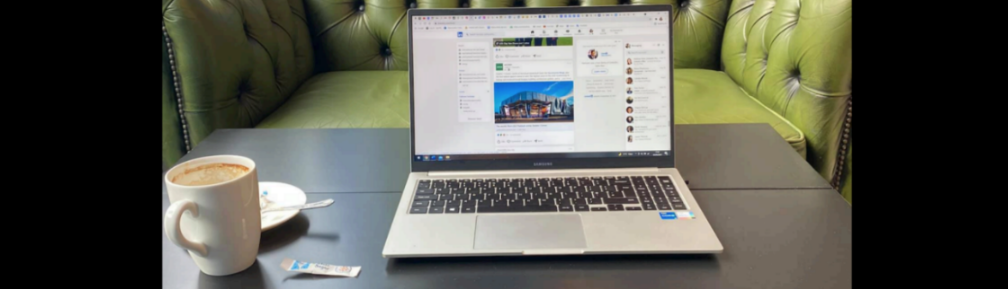

### Hemant Thapa 

##### 1. We define several activation functions such as Sigmoid, Softplus, ReLU, Tanh, Leaky ReLU, and ELU. These functions introduce nonlinearity to the model, allowing it to learn complex patterns and relationships in the data.

##### 2. We generate noisy data based on these activation functions. This noisy data simulates real-world scenarios where the relationship between input and output is not perfectly linear and contains some level of noise or randomness.

##### 3. We train neural network models using the generated noisy data and the defined activation functions. The neural network architecture includes layers with activation functions, allowing the model to learn the underlying nonlinear relationships in the data.

##### 4. After training the models, we make predictions on the input data using the trained models. These predictions are compared against the noisy data to evaluate the model's performance in capturing the nonlinear relationships.

##### 5. We visualise the original noisy data along with the predictions made by the trained models. This allows us to visually inspect how well the models have learned the nonlinear patterns present in the data.

In [63]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import scipy.stats as stats

In [7]:
num_scale = np.linspace(-10, 10, 1000)

In [9]:
class ActivationFunction:
    def __init__(self, x_values):
        self.x_values = x_values
        
    def sigmoid(self):
        return 1 / (1 + np.exp(-self.x_values))

    def softplus(self):
        return np.log(1 + np.exp(self.x_values))

    def relu(self):
        return np.maximum(0, self.x_values)

    def tanh(self):
        return np.tanh(self.x_values)

    def leaky_relu(self):
        return np.maximum(0.1 * self.x_values, self.x_values)

    def elu(self):
        return np.where(self.x_values >= 0, self.x_values, np.exp(self.x_values) - 1)

In [11]:
sigmoid_scale = ActivationFunction(num_scale).sigmoid()
softplus_scale = ActivationFunction(num_scale).softplus()
relu_scale = ActivationFunction(num_scale).relu()
tanh_scale = ActivationFunction(num_scale).tanh()
leaky_relu_scale = ActivationFunction(num_scale).leaky_relu()
elu_scale = ActivationFunction(num_scale).elu()

In [13]:
def plot_activation_function(num_scale, y_scale, label):
    plt.figure(figsize=(8,6))
    plt.plot(num_scale, y_scale, label=label, lw=2, color='red')
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.legend()
    plt.grid(True, ls='--', color='blue', alpha=0.5)
    plt.show()

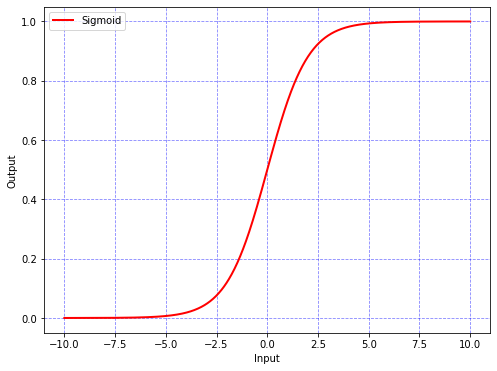

In [15]:
plot_activation_function(num_scale, sigmoid_scale, "Sigmoid")

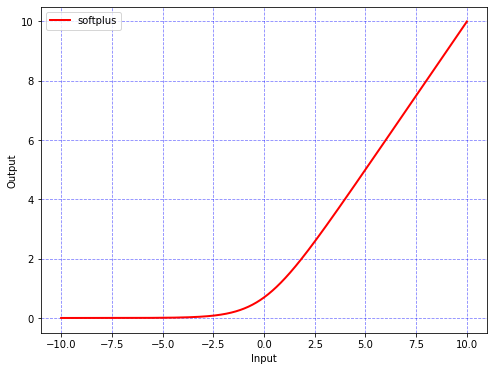

In [16]:
plot_activation_function(num_scale, softplus_scale, "softplus")

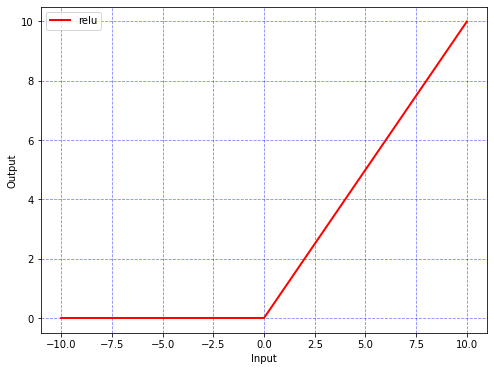

In [18]:
plot_activation_function(num_scale, relu_scale, "relu")

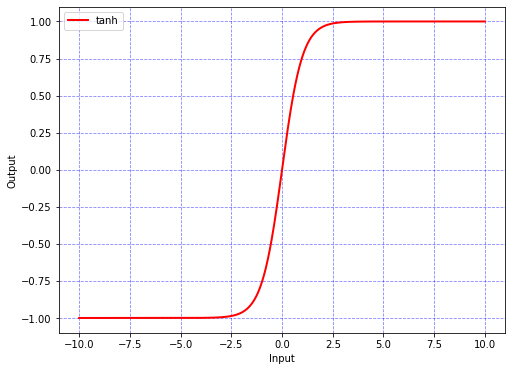

In [20]:
plot_activation_function(num_scale, tanh_scale, "tanh")

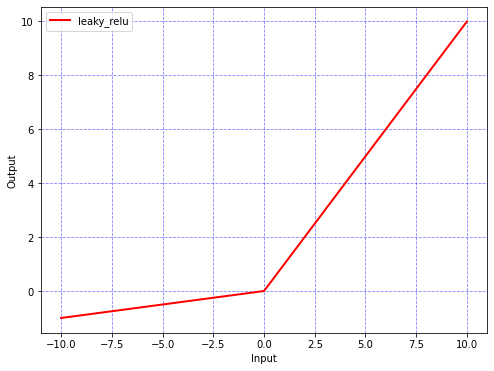

In [22]:
plot_activation_function(num_scale, leaky_relu_scale, "leaky_relu")

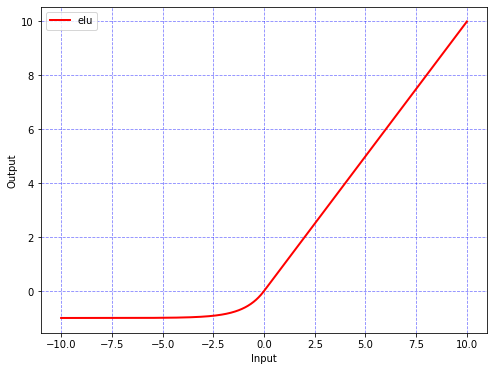

In [24]:
plot_activation_function(num_scale, elu_scale, "elu")

In [26]:
def plot_activation_functions_with_noise(x_values, y_noises, activation_functions):
    plt.figure(figsize=(20, 10))
    for i, (activation_function, y_noise) in enumerate(zip(activation_functions, y_noises), start=1):
        plt.subplot(2, 3, i)
        plt.scatter(x_values, y_noise, marker='s', color='black', s=10)
        plt.xlabel('Input')
        plt.ylabel('{} Output'.format(activation_function))
        plt.title('{} Function - Scatter Plot with Noise'.format(activation_function))
        plt.grid(True, ls='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [29]:
# noise to the y-values to make them vary around the curves
y_softplus_noise = softplus_scale + np.random.normal(0, 0.5, len(num_scale))  
y_relu_noise = relu_scale + np.random.normal(0, 0.5, len(num_scale))          
y_tanh_noise = tanh_scale + np.random.normal(0, 0.5, len(num_scale))          
y_leaky_relu_noise = leaky_relu_scale + np.random.normal(0, 0.5, len(num_scale))  
y_elu_noise = elu_scale + np.random.normal(0, 0.5, len(num_scale))              
y_sigmoid_noise = sigmoid_scale + np.random.normal(0, 0.5, len(num_scale))      

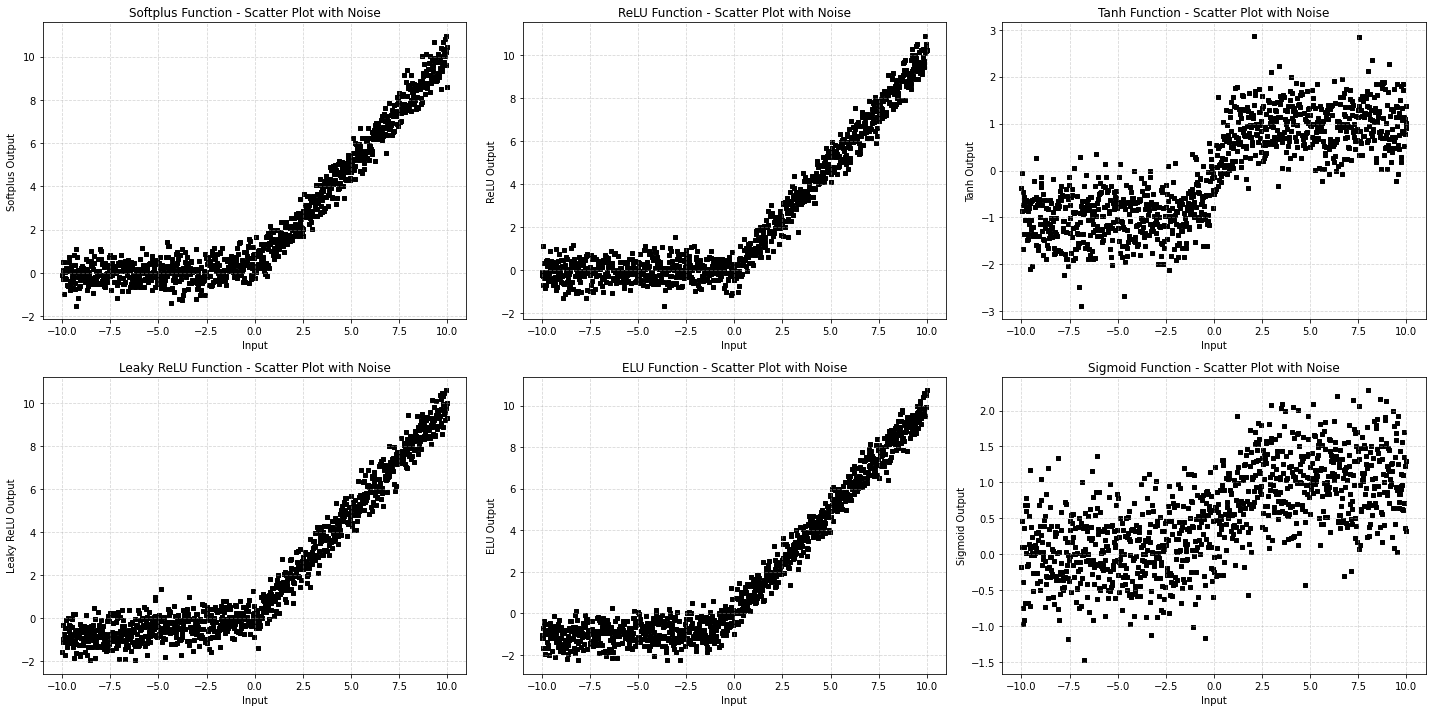

In [31]:
# activation functions
activation_functions = ['Softplus', 'ReLU', 'Tanh', 'Leaky ReLU', 'ELU', 'Sigmoid']

# scatter plots 
plot_activation_functions_with_noise(num_scale, [y_softplus_noise, y_relu_noise, y_tanh_noise,
                                                y_leaky_relu_noise, y_elu_noise, y_sigmoid_noise], activation_functions)

In [32]:
# neural network model
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(1,)),
        tf.keras.layers.Dense(1)
    ])
    return model

In [35]:
# Compile the model
def compile_model(model):
    model.compile(optimizer='adam', loss='mean_squared_error')

In [37]:
# Train the model
def train_model(model, x_train, y_train, epochs=100, verbose=0):
    model.fit(x_train, y_train, epochs=epochs, verbose=verbose)

In [39]:
# predict using the trained model
def predict_model(model, x_values):
    return model.predict(x_values)

In [41]:
# Plot the activation function with the noisy data and predicted line
def prediction_plot(x_values, y_noisy_list, y_pred_list, activation_functions):
    num_functions = len(activation_functions)
    num_rows = (num_functions + 2) // 3
    num_cols = min(3, num_functions)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5*num_rows))
    axes = axes.flatten()

    for i, (activation_function, y_noisy, y_pred) in enumerate(zip(activation_functions, y_noisy_list, y_pred_list)):
        ax = axes[i]
        ax.scatter(x_values, y_noisy, marker='o', color='black')
        ax.plot(x_values, y_pred, color='red', label='prediction')
        ax.set_xlabel('Input')
        ax.set_ylabel('Output')
        ax.set_title('{} Function with best fit Line'.format(activation_function))
        ax.legend()
        ax.grid(True, ls='--', alpha=0.5)
        
    for j in range(i+1, num_rows*num_cols):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

In [43]:
# predict for each activation function
y_noisy_list = [y_softplus_noise, y_relu_noise, y_tanh_noise, 
                y_leaky_relu_noise, y_elu_noise, y_sigmoid_noise]

y_pred_list = []

for i, y_noisy, y_values in zip(activation_functions, y_noisy_list, 
                                 [softplus_scale, relu_scale, tanh_scale,
                                  leaky_relu_scale, elu_scale, sigmoid_scale]):
    # reshape x and y 
    x_train = num_scale.reshape(-1, 1)
    y_train = y_noisy.reshape(-1, 1)
    
    # compile model
    model = create_model()
    compile_model(model)
    
    # train the model
    train_model(model, x_train, y_train, epochs=200)
    
    # predict using the model
    y_pred = predict_model(model, x_train)
    y_pred_list.append(y_pred)

32/32 [==============================] - 0s 898us/step


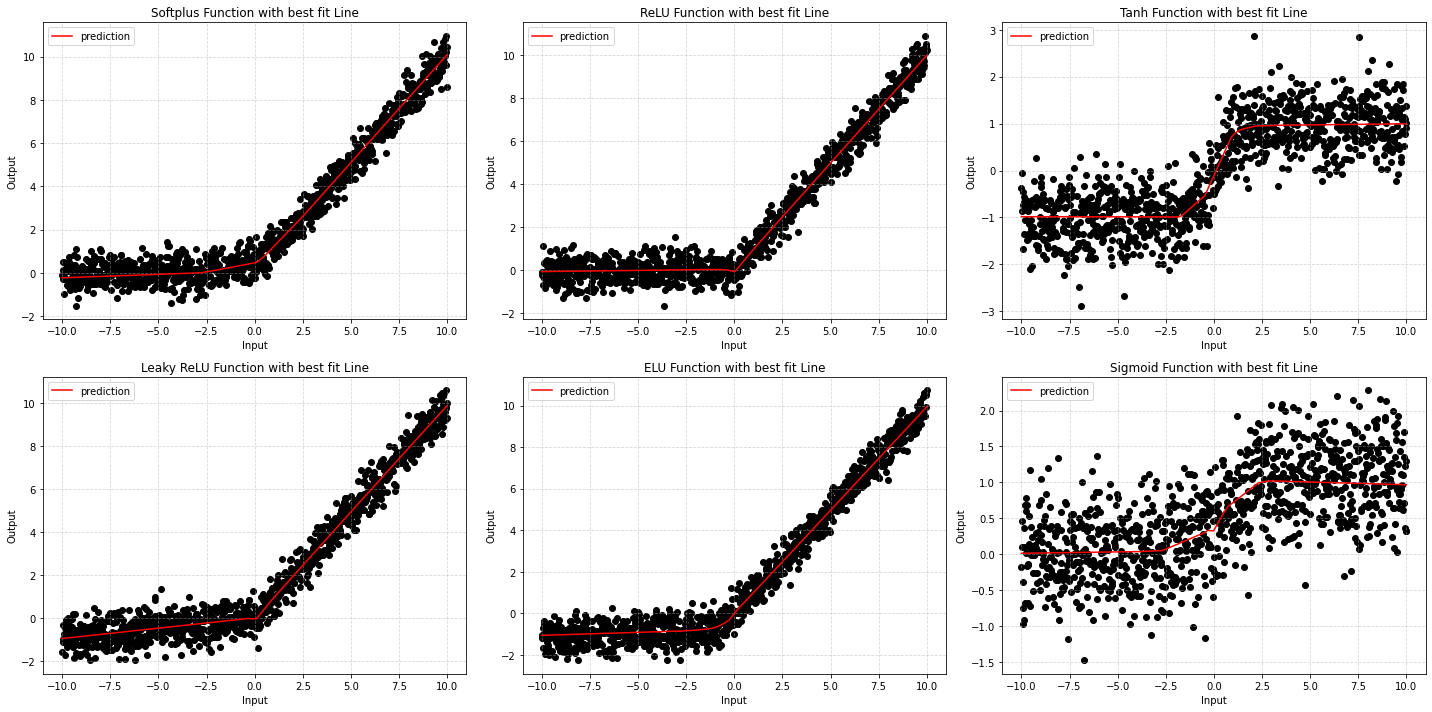

In [44]:
prediction_plot(num_scale, y_noisy_list, y_pred_list, activation_functions)

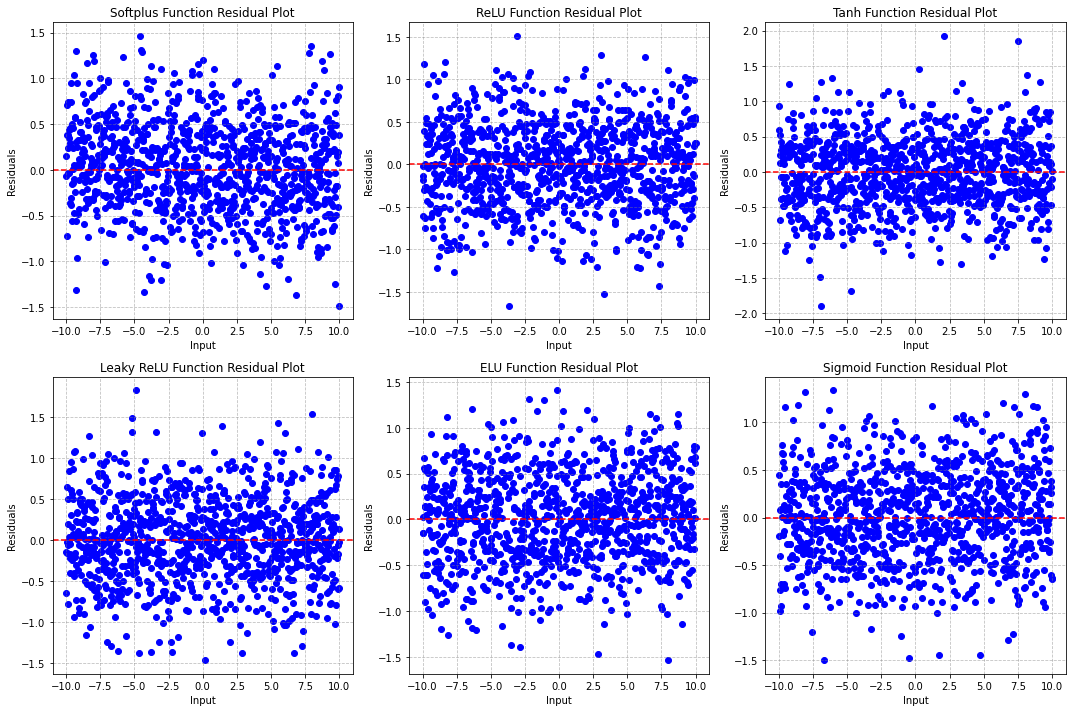

In [53]:
def residual_analysis(x_values, y_noisy_list, y_pred_list, activation_functions):
    num_functions = len(activation_functions)
    num_cols = 3  
    num_rows = (num_functions + num_cols - 1) // num_cols  

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5*num_rows))

    for i, (activation_function, y_noisy, y_pred) in enumerate(zip(activation_functions, y_noisy_list, y_pred_list)):
        row = i // num_cols 
        col = i % num_cols  
        ax = axes[row, col]  
        residuals = y_noisy - y_pred.flatten()  
        mean_residual = np.mean(residuals) 
        std_residual = np.std(residuals)  
        # residuals
        ax.scatter(x_values, residuals, marker='o', color='blue')
        ax.axhline(y=0, color='red', linestyle='--')
        ax.set_xlabel('Input')
        ax.set_ylabel('Residuals')
        ax.set_title('{} Function Residual Plot'.format(activation_function))
        ax.grid(True, ls='--', color='gray', alpha=0.5)
        
    for i in range(num_functions, num_rows * num_cols):
        fig.delaxes(axes.flatten()[i])
    plt.tight_layout()
    plt.show()
    
residual_analysis(num_scale, y_noisy_list, y_pred_list, activation_functions)

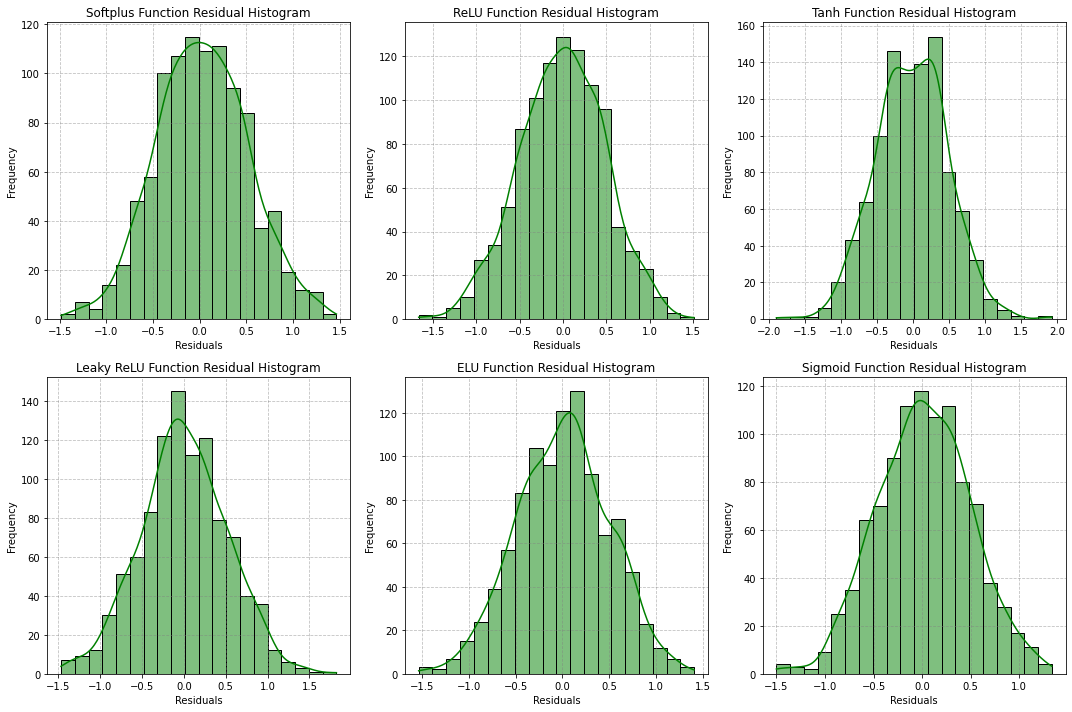

In [61]:
def hist_residual(x_values, y_noisy_list, y_pred_list, activation_functions):
    num_functions = len(activation_functions)
    num_cols = 3  
    num_rows = (num_functions + num_cols - 1) // num_cols  

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5*num_rows))

    for i, (activation_function, y_noisy, y_pred) in enumerate(zip(activation_functions, y_noisy_list, y_pred_list)):
        row = i // num_cols 
        col = i % num_cols  
        ax = axes[row, col]  
        residuals = y_noisy - y_pred.flatten()  

        # Histogram of residuals
        sns.histplot(residuals, kde=True, color='green', bins=20, ax=ax)
        ax.set_xlabel('Residuals')
        ax.set_ylabel('Frequency')
        ax.set_title('{} Function Residual Histogram'.format(activation_function))
        ax.grid(True, ls='--', color='gray', alpha=0.5)
        
    for i in range(num_functions, num_rows * num_cols):
        fig.delaxes(axes.flatten()[i])
    plt.tight_layout()
    plt.show()
    
hist_residual(num_scale, y_noisy_list, y_pred_list, activation_functions)

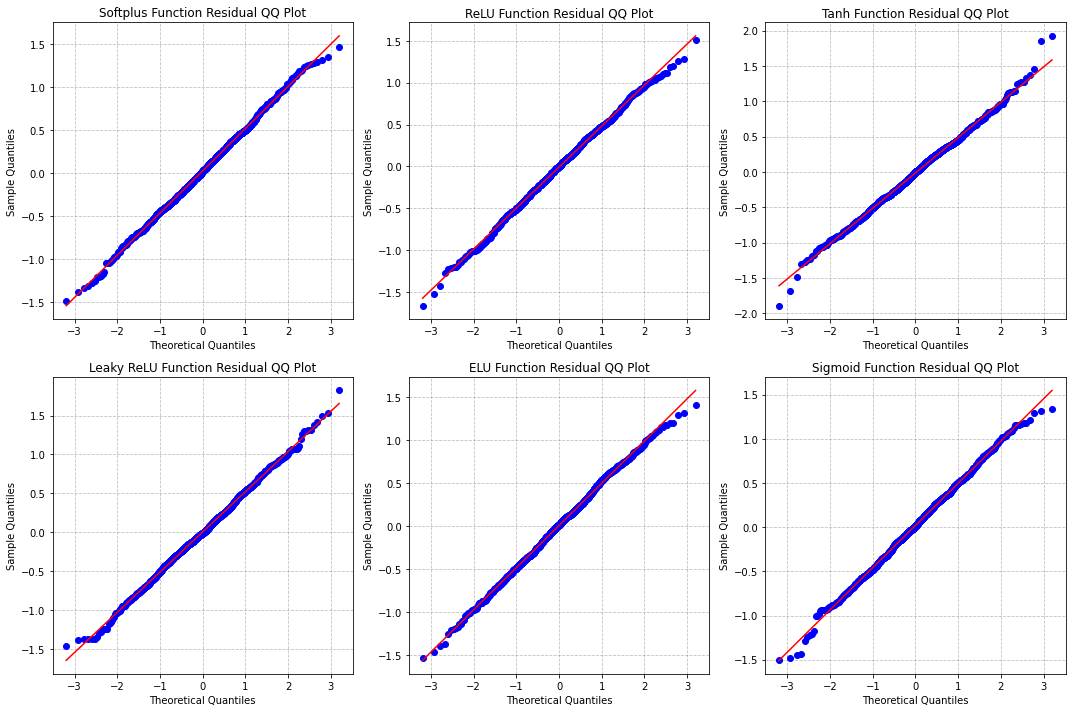

In [67]:
def QQ_residual(x_values, y_noisy_list, y_pred_list, activation_functions):
    num_functions = len(activation_functions)
    num_cols = 3  
    num_rows = (num_functions + num_cols - 1) // num_cols  

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5*num_rows))

    for i, (activation_function, y_noisy, y_pred) in enumerate(zip(activation_functions, y_noisy_list, y_pred_list)):
        row = i // num_cols 
        col = i % num_cols  
        ax = axes[row, col]  
        residuals = y_noisy - y_pred.flatten()  

        # QQ plot of residuals
        stats.probplot(residuals, dist="norm", plot=ax)
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Sample Quantiles')
        ax.set_title('{} Function Residual QQ Plot'.format(activation_function))
        ax.grid(True, ls='--', color='gray', alpha=0.5)
        
    for i in range(num_functions, num_rows * num_cols):
        fig.delaxes(axes.flatten()[i])
    plt.tight_layout()
    plt.show()
    
QQ_residual(num_scale, y_noisy_list, y_pred_list, activation_functions)

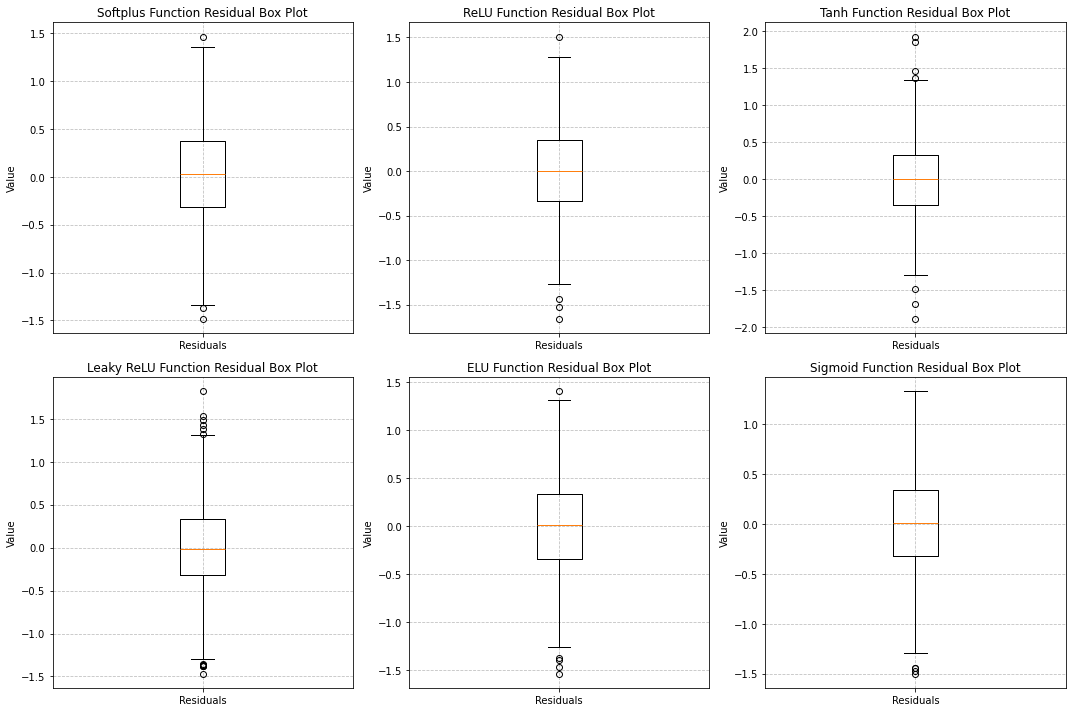

In [71]:
def box_residual(x_values, y_noisy_list, y_pred_list, activation_functions):
    num_functions = len(activation_functions)
    num_cols = 3  
    num_rows = (num_functions + num_cols - 1) // num_cols  

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5*num_rows))

    for i, (activation_function, y_noisy, y_pred) in enumerate(zip(activation_functions, y_noisy_list, y_pred_list)):
        row = i // num_cols 
        col = i % num_cols  
        ax = axes[row, col]  
        residuals = y_noisy - y_pred.flatten()  

        # Box plot of residuals
        ax.boxplot(residuals)
        ax.set_xticklabels(['Residuals'])
        ax.set_ylabel('Value')
        ax.set_title('{} Function Residual Box Plot'.format(activation_function))
        ax.grid(True, ls='--', color='gray', alpha=0.5)
        
    for i in range(num_functions, num_rows * num_cols):
        fig.delaxes(axes.flatten()[i])
    plt.tight_layout()
    plt.show()
    
box_residual(num_scale, y_noisy_list, y_pred_list, activation_functions)

References: 

[1] GeeksforGeeks. (n.d.). Implementing Neural Networks using TensorFlow. Retrieved from https://www.geeksforgeeks.org/implementing-neural-networks-using-tensorflow/

[2] TensorFlow. (n.d.). TensorFlow Quickstart for Beginners. Retrieved from https://www.tensorflow.org/tutorials/quickstart/beginner

[3] TensorFlow. (n.d.). TensorFlow Playground. Retrieved from https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.94023&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false
